### Deskripsi Dataset dan Tujuan Analisis
Dataset berisi data absensi dan nilai siswa. Tujuan analisis adalah mengklasifikasikan performa siswa menggunakan sistem fuzzy (Mamdani & Sugeno) serta membandingkan kinerjanya.

In [21]:
# Cell 1: Import Library
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Mengimpor dataset
df = pd.read_csv("data/dataset_siswa.csv")

# Memeriksa apakah ada missing values di dataset
print("\nMissing Values per Kolom:")
print(df.isnull().sum())

# Jika ada missing values, kita bisa mengisinya dengan rata-rata kolom masing-masing
df['absensi'] = df['absensi'].fillna(df['absensi'].mean())
df['nilai'] = df['nilai'].fillna(df['nilai'].mean())

# Memeriksa kembali setelah pengisian missing values
print("\nDataset Setelah Penanganan Missing Values:")
print(df.isnull().sum())

# Menampilkan informasi dasar dari dataset
print("\nInformasi Dataset:")
print(df.info())

# Menampilkan statistik deskriptif untuk atribut numerik
print("\nStatistik Deskriptif Dataset:")
print(df.describe())



Missing Values per Kolom:
nomor_id    0
absensi     0
nilai       0
dtype: int64

Dataset Setelah Penanganan Missing Values:
nomor_id    0
absensi     0
nilai       0
dtype: int64

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   nomor_id  150 non-null    object
 1   absensi   150 non-null    int64 
 2   nilai     150 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ KB
None

Statistik Deskriptif Dataset:
          absensi       nilai
count  150.000000  150.000000
mean    72.260000   71.446667
std     18.785411   17.711914
min     10.000000   16.000000
25%     61.000000   60.250000
50%     73.000000   72.000000
75%     88.000000   83.750000
max    100.000000  100.000000


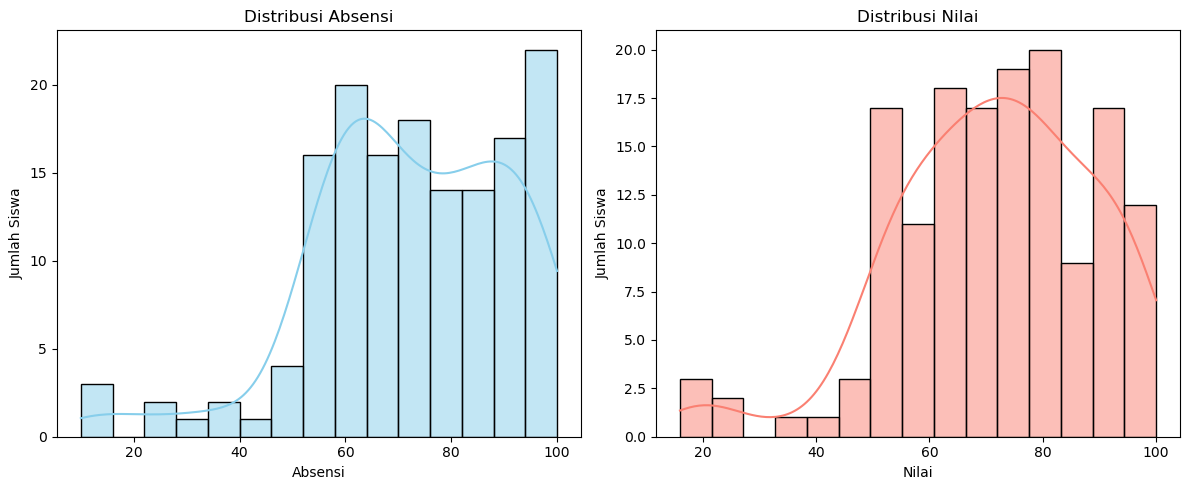

In [23]:
# Cell 3: Visualisasi Distribusi Data
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['absensi'], kde=True, bins=15, color='skyblue')
plt.title('Distribusi Absensi')
plt.xlabel('Absensi')
plt.ylabel('Jumlah Siswa')

plt.subplot(1,2,2)
sns.histplot(df['nilai'], kde=True, bins=15, color='salmon')
plt.title('Distribusi Nilai')
plt.xlabel('Nilai')
plt.ylabel('Jumlah Siswa')
plt.tight_layout()
plt.show()

### Statistik & Prapemrosesan Data

- Fitur yang digunakan: **absensi** dan **nilai**.
- Missing value diatasi dengan pengisian rata-rata kolom.
- Distribusi data divisualisasikan untuk memastikan tidak ada outlier ekstrem.

In [24]:
# Fungsi untuk mengkategorikan performa berdasarkan nilai dan absensi
def categorize_performance(row):
    if row['nilai'] < 50 and row['absensi'] < 50:
        return 'Buruk'
    elif (50 <= row['nilai'] <= 75) or (50 <= row['absensi'] <= 75):
        return 'Cukup'
    elif row['nilai'] > 75 and row['absensi'] > 75:
        return 'Bagus'

# Menambahkan kolom 'performa' berdasarkan kategori
df['performa'] = df.apply(categorize_performance, axis=1)

# Menampilkan contoh dataset setelah penambahan kolom performa
print("\nContoh Data Setelah Prapemrosesan:")
print(df.head(20))


Contoh Data Setelah Prapemrosesan:
   nomor_id  absensi  nilai performa
0     S1000       97     83    Bagus
1     S1001       98     92    Bagus
2     S1002      100     94    Bagus
3     S1003       90     51    Cukup
4     S1004       59     91    Cukup
5     S1005       61     93    Cukup
6     S1006       67     80    Cukup
7     S1007       44     33    Buruk
8     S1008       98     56    Cukup
9     S1009       35     23    Buruk
10    S1010       86     75    Cukup
11    S1011       24     41    Buruk
12    S1012       95     90    Bagus
13    S1013       91     75    Cukup
14    S1014       58     89    Cukup
15    S1015       15     45    Buruk
16    S1016       64     79    Cukup
17    S1017       54     61    Cukup
18    S1018       33     18    Buruk
19    S1019       83     58    Cukup


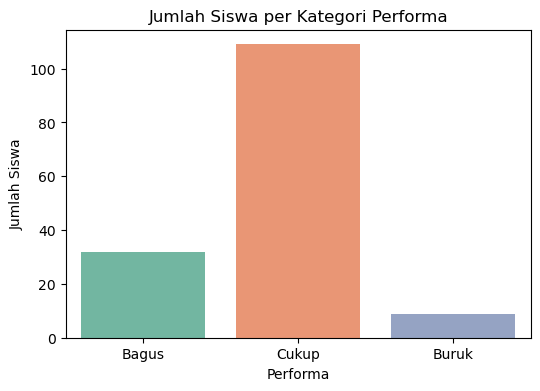

In [25]:
# Cell 5: Visualisasi Kategori Performa
plt.figure(figsize=(6,4))
sns.countplot(x='performa', hue='performa', data=df, palette='Set2', legend=False)
plt.title('Jumlah Siswa per Kategori Performa')
plt.xlabel('Performa')
plt.ylabel('Jumlah Siswa')
plt.show()

### Rancangan Fuzzy System

- **Atribut & Nilai Linguistik:**
  - Absensi: Rendah (0), Sedang (50), Tinggi (100)
  - Nilai: Buruk (0), Cukup (50), Bagus (100)

- **Fungsi Keanggotaan:**
  - Menggunakan fungsi Gaussian dengan pusat di 0, 50, 100 dan sigma 15.

- **Batas Nilai Linguistik:**
  - Rendah/Buruk: 0-50
  - Sedang/Cukup: 50-75
  - Tinggi/Bagus: 75-100

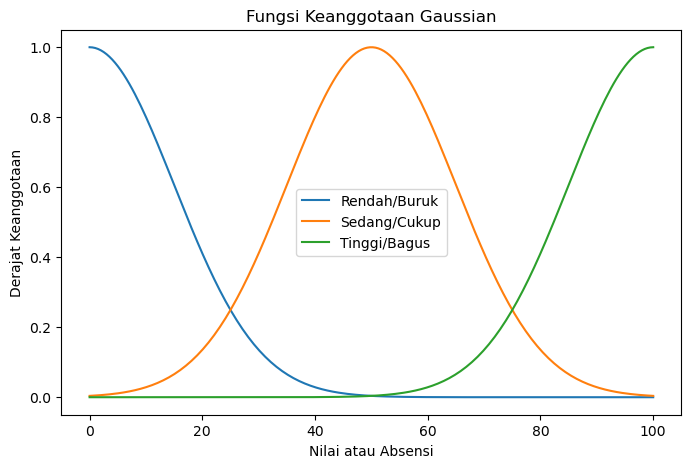

In [26]:
# Fungsi Keanggotaan Gaussian
def gaussian_membership(x, center, sigma):
    return np.exp(-0.5 * ((x - center) / sigma) ** 2)
x = np.linspace(0, 100, 200)
plt.figure(figsize=(8,5))
plt.plot(x, [gaussian_membership(i, 0, 15) for i in x], label='Rendah/Buruk')
plt.plot(x, [gaussian_membership(i, 50, 15) for i in x], label='Sedang/Cukup')
plt.plot(x, [gaussian_membership(i, 100, 15) for i in x], label='Tinggi/Bagus')
plt.title('Fungsi Keanggotaan Gaussian')
plt.xlabel('Nilai atau Absensi')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.show()

### Aturan Fuzzy (Rule Base)

- Jika absensi **rendah** dan nilai **buruk** → Performa **Buruk**
- Jika absensi **sedang** dan nilai **cukup** → Performa **Cukup**
- Jika absensi **tinggi** dan nilai **bagus** → Performa **Bagus**
- Lainnya → Performa **Cukup**

In [27]:

# Fungsi untuk menghitung performa berdasarkan Mamdani
def mamdani(absensi, nilai):
    # 1. Fuzzifikasi Input
    absensi_rendah = gaussian_membership(absensi, 0, 15)
    absensi_sedang = gaussian_membership(absensi, 50, 15)
    absensi_tinggi = gaussian_membership(absensi, 100, 15)

    nilai_buruk = gaussian_membership(nilai, 0, 15)
    nilai_cukup = gaussian_membership(nilai, 50, 15)
    nilai_bagus = gaussian_membership(nilai, 100, 15)

    # Nilai representatif crisp untuk output linguistik Mamdani
    # (Penyederhanaan dari himpunan fuzzy output penuh)
    PERFORMA_BURUK_CRISP = 0.0
    PERFORMA_CUKUP_CRISP = 0.5
    PERFORMA_BAGUS_CRISP = 1.0

    # 2. Evaluasi Aturan (Kekuatan Aktivasi - Alpha)
    # Menggunakan min untuk operator AND, sesuai standar fuzzy.
    # Aturan 1: Jika absensi rendah DAN nilai buruk MAKA Performa Buruk
    alpha_rule1 = min(absensi_rendah, nilai_buruk)
    
    # Aturan 2: Jika absensi tinggi DAN nilai bagus MAKA Performa Bagus
    alpha_rule2 = min(absensi_tinggi, nilai_bagus)

    # Aturan 3: Jika absensi sedang DAN nilai cukup MAKA Performa Cukup
    alpha_rule3 = min(absensi_sedang, nilai_cukup)
    
    # Aturan 4 (Default/Lainnya): Performa Cukup
    # Untuk aturan "lainnya", kita bisa menganggapnya memiliki kondisi yang
    # komplementer atau memberikan bobot dasar jika aturan lain tidak kuat.
    # Cara sederhana: jika aturan lain lemah, aturan default ini lebih berperan.
    # Atau, kita bisa definisikan kondisi eksplisit untuknya.
    # Untuk saat ini, kita akan fokus pada 3 aturan utama dan handle kasus
    # jika tidak ada aturan yang terpicu.

    # 3. Agregasi & "Defuzzifikasi" Sederhana (Weighted Average)
    # Ini adalah pendekatan yang menghasilkan output crisp numerik.
    numerator = (alpha_rule1 * PERFORMA_BURUK_CRISP) + \
                (alpha_rule2 * PERFORMA_BAGUS_CRISP) + \
                (alpha_rule3 * PERFORMA_CUKUP_CRISP)
    
    denominator = alpha_rule1 + alpha_rule2 + alpha_rule3

    if denominator == 0:
        # Jika tidak ada aturan utama yang aktif, gunakan logika "Lainnya -> Performa Cukup"
        return PERFORMA_CUKUP_CRISP 
    else:
        return numerator / denominator

# Fungsi untuk menghitung performa berdasarkan Sugeno
def sugeno(absensi, nilai):
    # 1. Fuzzifikasi Input
    absensi_rendah = gaussian_membership(absensi, 0, 15)
    absensi_sedang = gaussian_membership(absensi, 50, 15)
    absensi_tinggi = gaussian_membership(absensi, 100, 15)

    nilai_buruk = gaussian_membership(nilai, 0, 15)
    nilai_cukup = gaussian_membership(nilai, 50, 15)
    nilai_bagus = gaussian_membership(nilai, 100, 15)

    # Output numerik (konstanta) untuk konsekuen aturan Sugeno (orde nol)
    OUTPUT_BURUK = 0.0
    OUTPUT_CUKUP = 0.5
    OUTPUT_BAGUS = 1.0

    # 2. Evaluasi Aturan (Kekuatan Aktivasi - Alpha)
    # Menggunakan min untuk operator AND.
    # Aturan 1: Jika absensi rendah DAN nilai buruk MAKA output = 0
    alpha_rule1 = min(absensi_rendah, nilai_buruk)
    
    # Aturan 2: Jika absensi tinggi DAN nilai bagus MAKA output = 1
    alpha_rule2 = min(absensi_tinggi, nilai_bagus)

    # Aturan 3: Jika absensi sedang DAN nilai cukup MAKA output = 0.5
    alpha_rule3 = min(absensi_sedang, nilai_cukup)

    # 3. Agregasi (Rata-rata Terbobot dari output aturan)
    numerator = (alpha_rule1 * OUTPUT_BURUK) + \
                (alpha_rule2 * OUTPUT_BAGUS) + \
                (alpha_rule3 * OUTPUT_CUKUP)
    
    denominator = alpha_rule1 + alpha_rule2 + alpha_rule3

    if denominator == 0:
        # Jika tidak ada aturan utama yang aktif, gunakan logika "Lainnya -> Performa Cukup" (output 0.5)
        return OUTPUT_CUKUP
    else:
        return numerator / denominator
# --- Fungsi untuk memetakan output numerik ke label kategori ---
# (Dapat digunakan untuk kedua metode setelah mendapatkan output numerik)
def map_numeric_to_label(numeric_score, threshold_buruk=0.25, threshold_bagus=0.75):
    """Memetakan skor numerik ke label kategori performa."""
    if numeric_score < threshold_buruk:
        return "Buruk"
    elif numeric_score > threshold_bagus:
        return "Bagus"
    else:
        return "Cukup"


In [28]:
# Fungsi untuk evaluasi model
def evaluate_model(predictions, actual):
    accuracy = accuracy_score(actual, predictions)
    f1 = f1_score(actual, predictions, average='weighted', labels=['Buruk', 'Cukup', 'Bagus'], zero_division=1)
    return accuracy, f1

# Menambahkan kolom 'predictions' dengan menggunakan Mamdani atau Sugeno
df['predictions_mamdani_numeric'] = df.apply(lambda row: mamdani(row['absensi'], row['nilai']), axis=1)
df['predictions_sugeno_numeric'] = df.apply(lambda row: sugeno(row['absensi'], row['nilai']), axis=1)

# Evaluasi menggunakan Mamdani
df['predictions_mamdani_label'] = df['predictions_mamdani_numeric'].apply(map_numeric_to_label)
accuracy_mamdani, f1_mamdani = evaluate_model(df['predictions_mamdani_label'], df['performa'])
print(f"Evaluasi Mamdani:\nAccuracy: {accuracy_mamdani}\nF1-Score: {f1_mamdani}")

# Evaluasi menggunakan Sugeno
# Karena output Sugeno berupa angka, kita harus mengkonversinya ke kategori yang sesuai untuk perbandingan
def map_sugeno_discrete_to_label(value):
    if value == 0.0: return "Buruk"
    elif value == 1.0: return "Bagus"
    else: return "Cukup" # Asumsi 0.5 atau lainnya adalah Cukup
df['predictions_sugeno_label'] = df['predictions_sugeno_numeric'].apply(map_sugeno_discrete_to_label)
accuracy_sugeno, f1_sugeno = evaluate_model(df['predictions_sugeno_label'], df['performa'])
print(f"\nEvaluasi Sugeno:\nAccuracy: {accuracy_sugeno}\nF1-Score: {f1_sugeno}")


Evaluasi Mamdani:
Accuracy: 0.7066666666666667
F1-Score: 0.713595444650848

Evaluasi Sugeno:
Accuracy: 0.7266666666666667
F1-Score: 0.6116344916344917


In [29]:
# Menampilkan perbandingan hasil antara Mamdani dan Sugeno
print("\nPerbandingan Kinerja:")
print(f"Accuracy Mamdani: {accuracy_mamdani} | Accuracy Sugeno: {accuracy_sugeno}")
print(f"F1-Score Mamdani: {f1_mamdani} | F1-Score Sugeno: {f1_sugeno}")

# Kesimpulan berdasarkan evaluasi
if accuracy_mamdani > accuracy_sugeno:
    print("\nMetode Mamdani lebih baik berdasarkan akurasi.")
elif accuracy_mamdani < accuracy_sugeno:
    print("\nMetode Sugeno lebih baik berdasarkan akurasi.")
else:
    print("\nKedua metode memiliki akurasi yang sama.")

# Analisis hasil evaluasi Mamdani dan Sugeno
print("\nAnalisis:")
print(
    "Metode Mamdani dan Sugeno sama-sama menggunakan fungsi keanggotaan Gaussian dan aturan sederhana berbasis threshold.\nNamun, perbedaan utama terletak pada output: Mamdani menghasilkan label kategori langsung, sedangkan Sugeno menghasilkan output numerik yang kemudian dikonversi ke label.\n"
    "Jika akurasi dan F1-score Mamdani lebih tinggi, hal ini bisa terjadi karena aturan pada Mamdani lebih sesuai dengan pola data pada dataset, \natau karena proses konversi output Sugeno ke label menyebabkan informasi hilang.\n"
    "Sebaliknya, jika Sugeno lebih baik, kemungkinan aturan numerik Sugeno lebih fleksibel dalam menangkap variasi data.\n"
    "Perbedaan hasil juga bisa dipengaruhi oleh distribusi data pada fitur absensi dan nilai, serta parameter fungsi keanggotaan yang digunakan. \nUntuk meningkatkan kinerja, aturan fuzzy dan parameter fungsi keanggotaan dapat dioptimasi lebih lanjut."
)


Perbandingan Kinerja:
Accuracy Mamdani: 0.7066666666666667 | Accuracy Sugeno: 0.7266666666666667
F1-Score Mamdani: 0.713595444650848 | F1-Score Sugeno: 0.6116344916344917

Metode Sugeno lebih baik berdasarkan akurasi.

Analisis:
Metode Mamdani dan Sugeno sama-sama menggunakan fungsi keanggotaan Gaussian dan aturan sederhana berbasis threshold.
Namun, perbedaan utama terletak pada output: Mamdani menghasilkan label kategori langsung, sedangkan Sugeno menghasilkan output numerik yang kemudian dikonversi ke label.
Jika akurasi dan F1-score Mamdani lebih tinggi, hal ini bisa terjadi karena aturan pada Mamdani lebih sesuai dengan pola data pada dataset, 
atau karena proses konversi output Sugeno ke label menyebabkan informasi hilang.
Sebaliknya, jika Sugeno lebih baik, kemungkinan aturan numerik Sugeno lebih fleksibel dalam menangkap variasi data.
Perbedaan hasil juga bisa dipengaruhi oleh distribusi data pada fitur absensi dan nilai, serta parameter fungsi keanggotaan yang digunakan. 
Unt